In [6]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/feture 3sec/out_3sec_features.csv", header=None)

# Add '0' as the last column
df['label'] = 2

# Save the updated CSV
df.to_csv("out_3sec_binary_features.csv", index=False, header=False)

In [19]:
import pandas as pd

# Load CSV (or your DataFrame)
df = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/out_3sec_binary_features.csv')

# Drop the second-last column
df.drop(df.columns[-2], axis=1, inplace=True)

# Save back if needed
df.to_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/out_3sec_binary_features.csv', index=False)

In [20]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/a_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/i_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/u_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/in_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/out_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/up_3sec_binary_features.csv"
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("binary_labels.csv", index=False)

In [1]:
import pandas as pd

# List your CSV files directly
csv_files = ["/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/a_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/i_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/u_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/in_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/out_3sec_binary_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/up_3sec_binary_features.csv"
            ] 
# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    if df.columns[-1] == "5":
        df.drop("5", axis=1, inplace=True)  # Remove the column explicitly by label
    else:
        df.drop(df.columns[-1], axis=1, inplace=True)  # Fallback: drop last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('binary_combined.csv', index=False)

print("Combined CSV saved as 'combined.csv' without the last column '5'")

Combined CSV saved as 'combined.csv' without the last column '5'



===== Random Forest =====
Fold 1: Accuracy = 0.8159
Fold 2: Accuracy = 0.7905
Fold 3: Accuracy = 0.8167
Fold 4: Accuracy = 0.8302
Fold 5: Accuracy = 0.8040
Fold 6: Accuracy = 0.8040
Fold 7: Accuracy = 0.8032
Fold 8: Accuracy = 0.7976
Fold 9: Accuracy = 0.7921
Fold 10: Accuracy = 0.8286
Average Accuracy = 0.8083

===== Decision Tree =====
Fold 1: Accuracy = 0.7286
Fold 2: Accuracy = 0.7341
Fold 3: Accuracy = 0.7333
Fold 4: Accuracy = 0.7540
Fold 5: Accuracy = 0.7627
Fold 6: Accuracy = 0.7357
Fold 7: Accuracy = 0.7373
Fold 8: Accuracy = 0.7167
Fold 9: Accuracy = 0.7437
Fold 10: Accuracy = 0.7333
Average Accuracy = 0.7379

===== Gradient Boosting =====
Fold 1: Accuracy = 0.8000
Fold 2: Accuracy = 0.7794
Fold 3: Accuracy = 0.8040
Fold 4: Accuracy = 0.8000
Fold 5: Accuracy = 0.7857
Fold 6: Accuracy = 0.7937
Fold 7: Accuracy = 0.8032
Fold 8: Accuracy = 0.7698
Fold 9: Accuracy = 0.7698
Fold 10: Accuracy = 0.8095
Average Accuracy = 0.7915


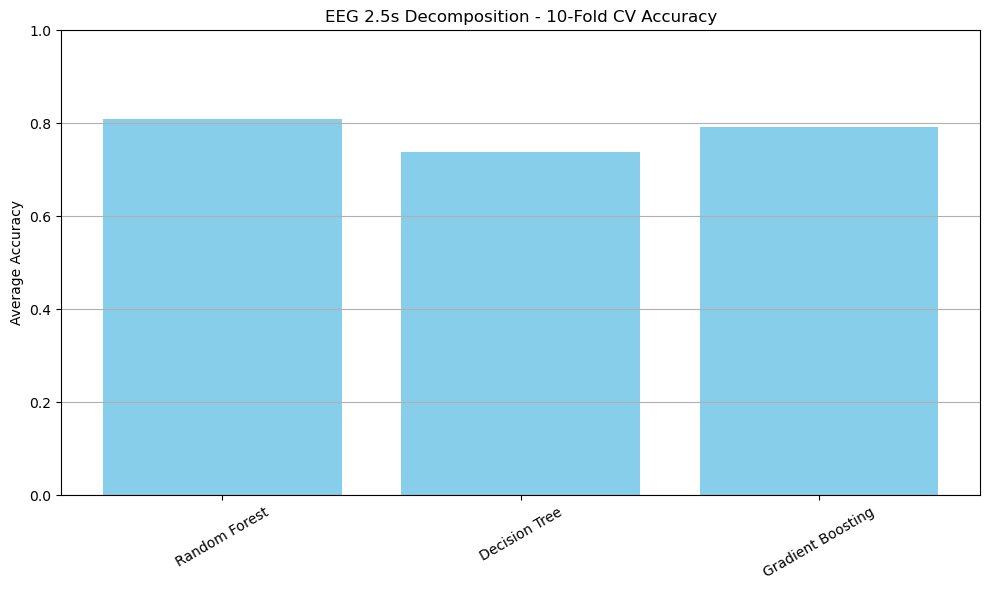

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/binary_combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/binary classification (very long vs short)/binary_labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()